## Navier-Stokes fluid with a cilinder obstacle (2D)

Simulation of a fluid following the 2D incompressible, laminar, steady-state Navier Stokes equations (NSEs). The equations are, respectively, mass conservation, $x$ and $y$ direction momentum conservation.
\begin{gather*}
\dfrac{\partial u}{\partial x} + \dfrac{\partial v}{\partial y} = 0\\
u\dfrac{\partial u}{\partial x} + v\dfrac{\partial u}{\partial y} = -\dfrac{1}{\rho}\dfrac{\partial p}{\partial x}+ \nu \left(\dfrac{\partial^2 u}{\partial x^2} + \dfrac{\partial^2 u}{\partial y^2} \right)\\
u\dfrac{\partial v}{\partial x} + v\dfrac{\partial v}{\partial y} = -\dfrac{1}{\rho}\dfrac{\partial p}{\partial y}+ \nu \left(\dfrac{\partial^2 v}{\partial x^2} + \dfrac{\partial^2 v}{\partial y^2} \right)
\end{gather*}
Or written in a concise way,
\begin{gather*}
\nabla \cdot \boldsymbol{u} = 0\\
(\boldsymbol{u}\cdot \nabla)\boldsymbol{u}=-\nabla p+\nu \nabla^2\boldsymbol{u}
\end{gather*}
Where $u$ is the velocity in the $x$ direction, $v$ in the $y$ direction, $p$ is the pressure, $\rho$ the density and $\nu$ the kinematic viscosity. 

The system consists of a 2D rectangle of length $L=1~m$ and width $d = 0.4~m$, with a cylinder obstacle of radius $R=0.05~m$ located at the origin. The fluid has density $\rho = 1~kg/m^3$ and we have studied the case $\nu=0.01~m^2/s$. 

The boundary conditions are the following: 
- At the entrance (inlet), $u=u_{\text{inlet}}$ and $v=0$.
- At the exit (outlet), $p=0$
- At the walls (including the cylinder), $u=v=0$

The function $u=u_{\text{inlet}}$ is a parabola that satisfies that $u=0$ at the top and bottom walls in the entrance. This is done because, if $u$ was the same at every point of the inlet, then there would be a conflict with the third condition, that $u=0$ at the wall. This would cause the gradient of the neural network to explode. The function is the following parabolla:
\begin{equation*}
u_{\text{inlet}} = u_{0}\left(1 - \left(\dfrac{y}{d_{obs}}\right)^2\right)
\end{equation*}
where $u_0$ is the maximum velocity (set to 1 $m/s$ in this case) at the entrance and $d_{obs}$ is the distance from the origin to the inlet.

We define the equations that must be satisfied at the pde(x,y) function, and we use the library DeepXDE for creating the model. We define the geometry of the system, and the boundary conditions following the conditions specified previously. 

We choose a total of $4000$ points around the domain, and another $1500$ specifically at the boundaries. For the network to correctly respect the obstacle, we add $3000$ points around the cylinder (a circle of radius $3R$). With these points, we start training with Adam and then refine it with L-BFGS.

### Imports 

In [6]:
import deepxde as dde
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt

In [7]:
# Set default float type to float32 for better performance

dde.config.set_default_float("float32")

Set the default float type to float32


### Geometry and PDE definition

In [8]:
R = 0.05 # radius of the cylinder

geom_rect = dde.geometry.Rectangle(xmin=[-0.2, -0.2], xmax=[0.8, 0.2]) # 1m long and 0.4m wide
geom_cyl = dde.geometry.Disk([0.0, 0.0], R) # cylinder centered at the origin with radius R
geom = dde.geometry.CSGDifference(geom_rect, geom_cyl)

In [9]:
def pde(x, y):
    """
    Function that defines the Navier-Stokes equations for incompressible flow in 2D.
    Args:
        x: Tensor of shape (N, 2) containing the coordinates (x, y) of the points where the PDE is evaluated.
        y: Tensor of shape (N, 3) containing the predicted values of (u, v, p) at the points in 'x'.
    Returns:
        A list of three tensors representing the residuals of the continuity equation.
    """
     
    u = y[:, 0:1]
    v = y[:, 1:2]

    nu = 0.01

    u_x = dde.grad.jacobian(y, x, i=0, j=0)
    u_y = dde.grad.jacobian(y, x, i=0, j=1)
    v_x = dde.grad.jacobian(y, x, i=1, j=0)
    v_y = dde.grad.jacobian(y, x, i=1, j=1)
    p_x = dde.grad.jacobian(y, x, i=2, j=0)
    p_y = dde.grad.jacobian(y, x, i=2, j=1)

    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    u_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    v_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)

    continuity = u_x + v_y
    momentum_x = u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    momentum_y = u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

    return [continuity, momentum_x, momentum_y]

### Boundaries definitions

In [10]:
u_max = 1.0 # maximum velocity at the center of the inlet
h_max = 0.2 # distance from center to wall

def u_inlet(x): # parabolic velocity profile at the inlet
    y = x[:, 1:2]
    return u_max * (1 - (y / h_max) ** 2)

def inlet(x, on_boundary): # function to identify the inlet boundary
    return on_boundary and np.isclose(x[0], -0.2)

bc_in_u = dde.DirichletBC(geom, u_inlet, inlet, component=0)
bc_in_v = dde.DirichletBC(geom, lambda x: 0, inlet, component=1)

def outlet(x, on_boundary): # function to identify the outlet boundary
    return on_boundary and np.isclose(x[0], 0.8)

bc_out_p = dde.DirichletBC(geom, lambda x: 0, outlet, component=2)

def walls(x, on_boundary): # function to identify the top and bottom walls
    return on_boundary and (np.isclose(x[1], -0.2) or np.isclose(x[1], 0.2))

bc_wall_u = dde.DirichletBC(geom, lambda x: 0, walls, component=0)
bc_wall_v = dde.DirichletBC(geom, lambda x: 0, walls, component=1)

def cylinder(x, on_boundary): # function to identify the cylinder boundary
    r = np.sqrt(x[0]**2 + x[1]**2)
    return on_boundary and np.isclose(r, R, atol=1e-3)

bc_cyl_u = dde.DirichletBC(geom, lambda x: 0, cylinder, component=0)
bc_cyl_v = dde.DirichletBC(geom, lambda x: 0, cylinder, component=1)

### Data points

In [11]:
# Generating extra points around the obstacle (3 times the radius of the cylinder)

num_points_cilinder = 3000
r_rand = np.random.uniform(R, 3*R, num_points_cilinder)
theta_rand = np.random.uniform(0, 2*np.pi, num_points_cilinder)

x_rand = r_rand * np.cos(theta_rand)
y_rand = r_rand * np.sin(theta_rand)

cylinder_points = np.vstack((x_rand, y_rand)).T

In [12]:
data = dde.data.PDE(
    geom,
    pde,
    [bc_in_u, bc_in_v, bc_out_p, bc_wall_u, bc_wall_v, bc_cyl_u, bc_cyl_v],
    num_domain=4000,
    num_boundary=1500,
    anchors=cylinder_points
)

### Model definition and training

In [13]:
net = dde.nn.FNN([2] + [64]*5 + [3], "tanh", "Glorot uniform")
model = dde.Model(data, net)

In [ ]:
weights = [1.0, 1.0, 1.0,  5.0, 5.0,  1.0,  5.0, 5.0,  20.0, 20.0] # PDE, inlet BC, outlet BC, wall BC, cylinder BC

model.compile("adam", lr=1e-3, loss_weights=weights)
model.train(iterations=10000)

model.compile("adam", lr=5e-4, loss_weights=weights)
model.train(iterations=15000)

model.compile("L-BFGS")
model.train()

Compiling model...
'compile' took 0.013906 s



In [ ]:
#model.save("pinn_cylinder_model") 

# 'pinn_cylinder_model-25000.weights.h5' took 112 minutes to train, nu = 0.01, Re = 10

'pinn_cylinder_model-25000.weights.h5'

### Plotting

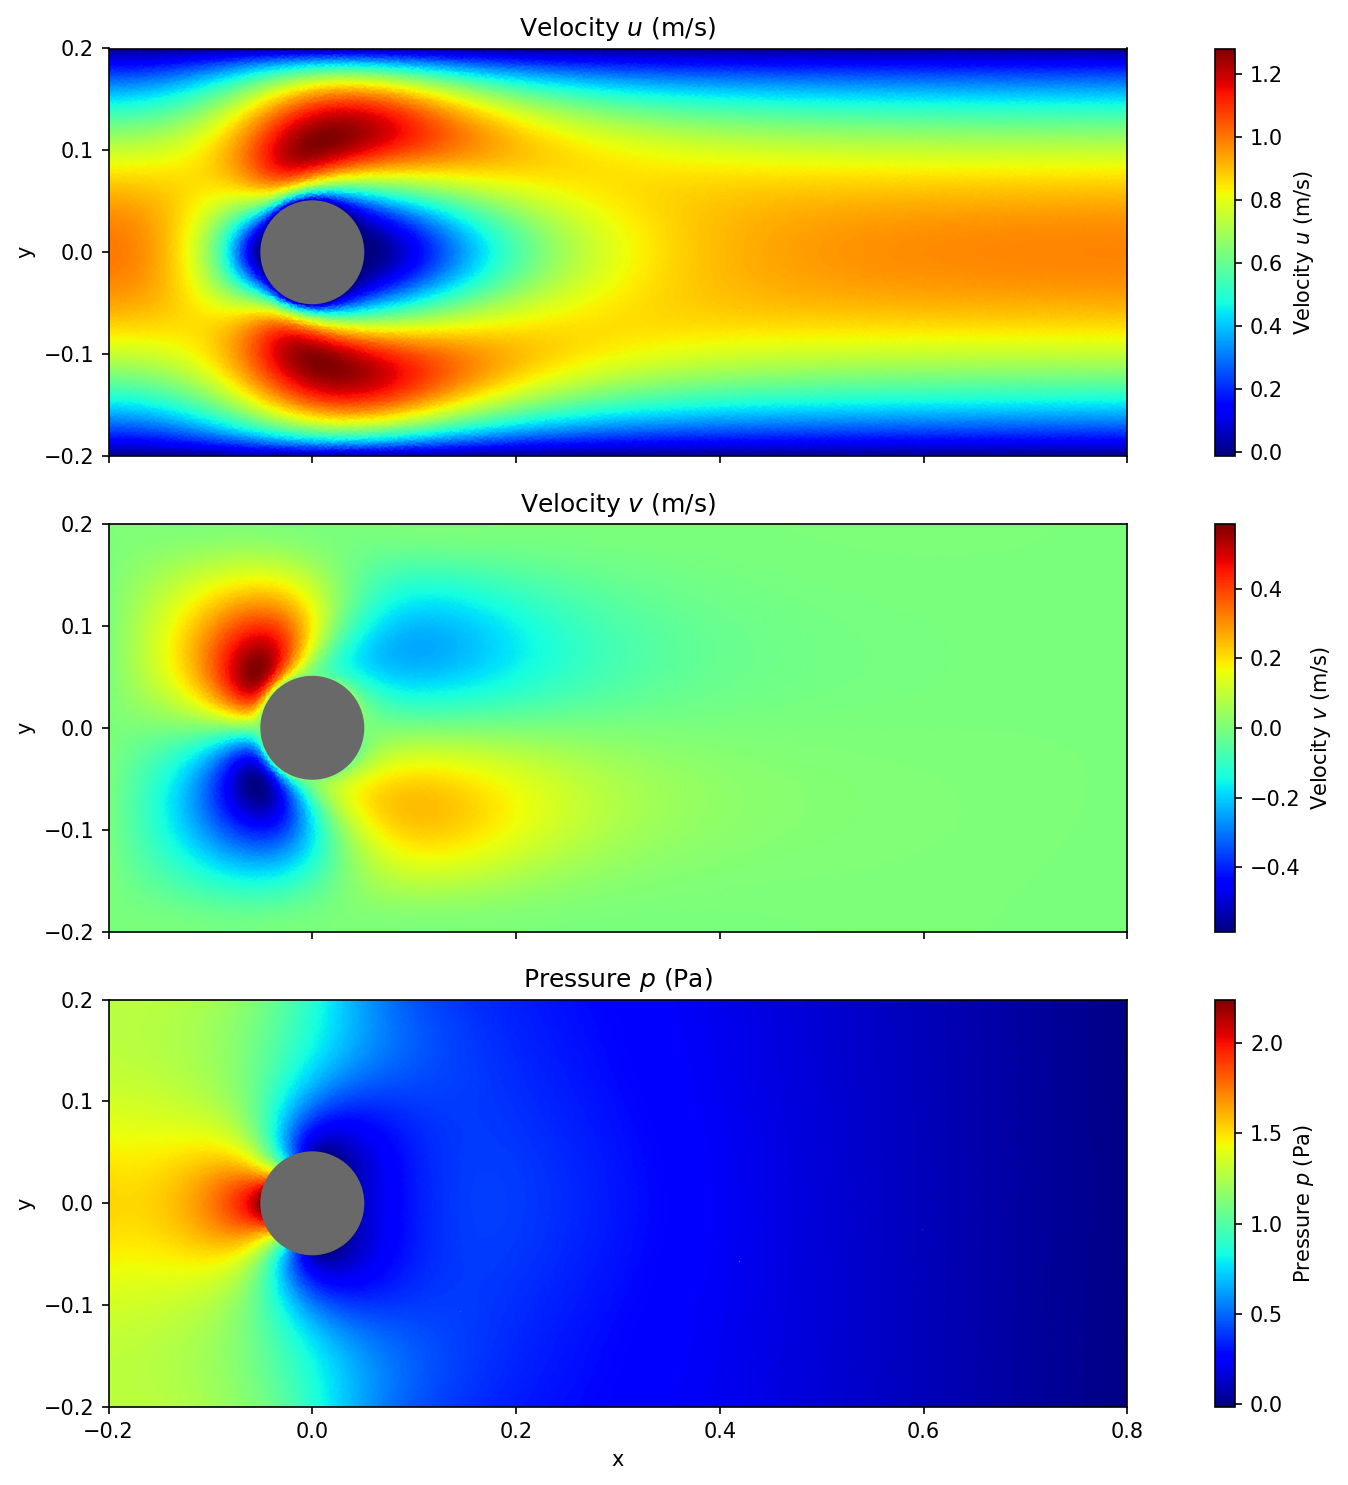

In [17]:
from matplotlib.patches import Circle

# Predict and plot results (suposant que 'geom', 'model', 'samples' i 'R' estan definits)
samples = geom.random_points(500000)
result = model.predict(samples)

magnituds = [f"Velocity $u$ (m/s)", f"Velocity $v$ (m/s)", f"Pressure $p$ (Pa)"]

# Creem la figura amb 3 files i 1 columna
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True, dpi=150)

# Extraiem els límits exactes del domini
xmin, xmax = samples[:, 0].min(), samples[:, 0].max()
ymin, ymax = samples[:, 1].min(), samples[:, 1].max()

for idx, ax in enumerate(axes):
    # Dibuixem el fluid
    sc = ax.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=0.5)
    
    # Afegim el cilindre (S'ha de crear una instància nova dins del bucle!)
    obstacle = Circle((0.0, 0.0), R, color='dimgray', zorder=10)
    ax.add_patch(obstacle)
    
    # Ajustem l'escala perquè el cercle no es deformi
    ax.set_aspect('equal')
    
    # Forcem els límits per ajustar el gràfic a les dades
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    # Marquem els eixos de manera neta
    ax.set_xticks(np.linspace(xmin, xmax, 6))
    ax.set_yticks(np.linspace(ymin, ymax, 5))
    
    # Títols i etiquetes
    ax.set_title(f"{magnituds[idx]}")
    ax.set_ylabel("y")
    
    # Barra de colors
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(magnituds[idx])

# L'etiqueta x només a la part inferior
axes[-1].set_xlabel("x")

# Ajustem els espais per a una presentació neta
plt.tight_layout()    
plt.show()